# 03 — Sentiment Modelling

Inputs: `../data/grab_reviews_clean.csv`  
Outputs: `../models/tfidf-grab/tfidf_lr.joblib`, `../data/grab_reviews_with_predictions.csv`

Pipeline:
1. VADER baseline (rule-based, no training)
2. TF-IDF + Logistic Regression classifier (scikit-learn)
3. Evaluate both with Precision / Recall / F1 per class

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)

df = pd.read_csv('../data/grab_reviews_clean.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} reviews')
print(df['sentiment'].value_counts())

Loaded 5,333 reviews
sentiment
negative    2724
positive    2372
neutral      237
Name: count, dtype: int64


## 1. VADER Baseline

In [2]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_label(text: str) -> str:
    compound = sia.polarity_scores(text)['compound']
    if compound <= -0.05:
        return 'negative'
    elif compound >= 0.05:
        return 'positive'
    return 'neutral'

df['vader_pred'] = df['review_clean'].apply(vader_label)

print('VADER Classification Report:')
print(classification_report(df['sentiment'], df['vader_pred'], digits=3))

VADER Classification Report:
              precision    recall  f1-score   support

    negative      0.887     0.646     0.747      2724
     neutral      0.065     0.215     0.100       237
    positive      0.757     0.819     0.787      2372

    accuracy                          0.704      5333
   macro avg      0.570     0.560     0.545      5333
weighted avg      0.792     0.704     0.736      5333



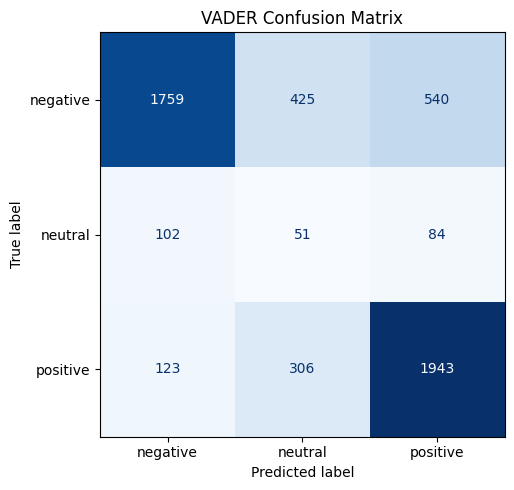

In [3]:
cm_vader = confusion_matrix(df['sentiment'], df['vader_pred'], labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vader, display_labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('VADER Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/03_vader_cm.png', dpi=120)
plt.show()

## 2. TF-IDF + Logistic Regression

Vectorises reviews with TF-IDF (unigrams + bigrams), then trains a Logistic Regression classifier. Pure scikit-learn — no torch, no transformers, no extra installs required.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
import joblib

SAMPLE_SIZE = None  # set to e.g. 2000 for a quick test run

In [5]:
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label  = {v: k for k, v in label2id.items()}

df_model = df[['review_clean', 'sentiment']].dropna().copy()
df_model['label'] = df_model['sentiment'].map(label2id)

if SAMPLE_SIZE:
    df_model = df_model.sample(SAMPLE_SIZE, random_state=42)

train_df, test_df = train_test_split(df_model, test_size=0.2, stratify=df_model['label'], random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.1, stratify=train_df['label'], random_state=42)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 3,839 | Val: 427 | Test: 1,067


In [6]:
clf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1, 2), sublinear_tf=True)),
    ('lr',    LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
])

clf.fit(train_df['review_clean'], train_df['label'])

val_preds = clf.predict(val_df['review_clean'])
print(f'Val accuracy: {accuracy_score(val_df["label"], val_preds):.3f}')
print(f'Val F1 macro: {f1_score(val_df["label"], val_preds, average="macro"):.3f}')

Val accuracy: 0.878
Val F1 macro: 0.599


## 3. Evaluate on Test Set

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

preds = clf.predict(test_df['review_clean'])
true  = test_df['label'].values

print('TF-IDF + LR Classification Report:')
print(classification_report(true, preds, target_names=['negative', 'neutral', 'positive'], digits=3))

TF-IDF + LR Classification Report:
              precision    recall  f1-score   support

    negative      0.824     0.976     0.893       545
     neutral      0.000     0.000     0.000        47
    positive      0.955     0.846     0.897       475

    accuracy                          0.875      1067
   macro avg      0.593     0.607     0.597      1067
weighted avg      0.846     0.875     0.856      1067



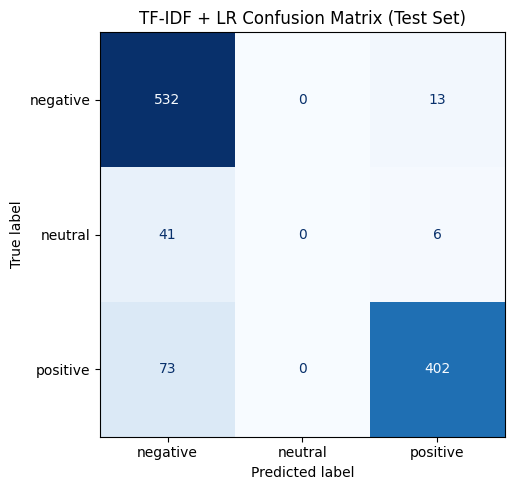

In [8]:
cm = confusion_matrix(true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('TF-IDF + LR Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('../data/03_tfidf_cm.png', dpi=120)
plt.show()

## 4. Predict on Full Dataset and Save

In [ ]:
full_preds = clf.predict(df['review_clean'])
full_proba = clf.predict_proba(df['review_clean'])

df['model_pred']  = [id2label[p] for p in full_preds]
df['model_score'] = full_proba.max(axis=1)

df.to_csv('../data/grab_reviews_with_predictions.csv', index=False)
print('Saved predictions to ../data/grab_reviews_with_predictions.csv')
df[['review_clean', 'sentiment', 'vader_pred', 'model_pred', 'model_score']].head()

## 5. Save Model

In [10]:
os.makedirs('../models/tfidf-grab', exist_ok=True)
joblib.dump(clf, '../models/tfidf-grab/tfidf_lr.joblib')
print('Model saved to ../models/tfidf-grab/tfidf_lr.joblib')

Model saved to ../models/tfidf-grab/tfidf_lr.joblib
